<a href="https://colab.research.google.com/github/samrat-rm/Brain-Cache/blob/main/LoanTap_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LoanTap Logistic Regression


**(A Scaler Business case study)**

Date: 9 June 2026

### Context:

LoanTap is an online platform committed to delivering customized loan products to millennials. They innovate in an otherwise dull loan segment, to deliver instant, flexible loans on consumer friendly terms to salaried professionals and businessmen.

The data science team at LoanTap is building an underwriting layer to determine the creditworthiness of MSMEs as well as individuals.

LoanTap deploys formal credit to salaried individuals and businesses 4 main financial instruments:

- Personal Loan
- EMI Free Loan
- Personal Overdraft
- Advance Salary Loan


This case study will focus on the underwriting process behind Personal Loan only.



### Problem Statement:

Given a set of attributes for an Individual, determine if a credit line should be extended to them. If so, what should the repayment terms be in business recommendations?

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("/content/logistic_regression.csv")
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


## Understanding the data



In [9]:
df.shape

(396030, 27)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

### Categorical Data

In [11]:
df.select_dtypes(include='object').columns

Index(['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'title', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='object')

Now, Lets understand each column and each column's descrition.

Data dictionary:


- term : The number of payments on the loan. Values are in months and can be either 36 or 60.
- grade : LoanTap assigned loan grade
- sub_grade : LoanTap assigned loan subgrade
- emp_title :The job title supplied by the Borrower when applying for the loan.
- emp_length : Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.
- home_ownership : The home ownership status provided by the borrower during registration or obtained from the credit report.
- verification_status : Indicates if income was verified by LoanTap, not verified, or if the income source was verified
- issue_d : The month which the loan was funded
- loan_status : Current status of the loan - Target Variable
- purpose : A category provided by the borrower for the loan request.
- title : The loan title provided by the borrower
- earliest_cr_line :The month the borrower's earliest reported
- initial_list_status : The initial listing status of the loan. Possible values are – W, F
- application_type : Indicates whether the loan is an individual application or a joint application with two co-borrowers
- Address: Address of the individual

In [12]:
df['term'].value_counts()

,count
term,
36 months,302005
60 months,94025


In [13]:
df['grade'].value_counts()

,count
grade,
B,116018
C,105987
A,64187
D,63524
E,31488
F,11772
G,3054


Each of the 6 grade has 5 sub grades. Eg: A1 - A5 , B1 - B5...

In [14]:
len(df['sub_grade'].value_counts())

35

In [15]:
len(df['emp_title'].unique())

173106

In [16]:
df['emp_length'].value_counts()

,count
emp_length,
10+ years,126041
2 years,35827
< 1 year,31725
3 years,31665
5 years,26495
1 year,25882
4 years,23952
6 years,20841
7 years,20819


In [17]:
df['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,198348
RENT,159790
OWN,37746
OTHER,112
NONE,31
ANY,3


- OTHER: This category typically refers to housing situations that don't fit into the standard categories like 'MORTGAGE', 'RENT', or 'OWN'. It could include living with relatives without paying rent, living in employer-provided housing, or other less common arrangements.
- NONE: This usually means the borrower does not own a home and is not renting. They might be living rent-free with family or friends, or in a transitional living situation.
- ANY: This is a less common category, but it could imply a broad or unspecified form of ownership, or it might be a catch-all for various non-standard situations.

In [18]:
df['verification_status'].value_counts()

,count
verification_status,
Verified,139563
Source Verified,131385
Not Verified,125082


In [19]:
df['issue_d']

,issue_d
0,Jan-2015
1,Jan-2015
2,Jan-2015
3,Nov-2014
4,Apr-2013
...,...
396025,Oct-2015
396026,Feb-2015
396027,Oct-2013
396028,Aug-2012


In [20]:
df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,318357
Charged Off,77673


In [21]:
df['purpose'].value_counts()

,count
purpose,
debt_consolidation,234507
credit_card,83019
home_improvement,24030
other,21185
major_purchase,8790
small_business,5701
car,4697
medical,4196
moving,2854


In [22]:
df['title'].value_counts()[:20]

,count
title,
Debt consolidation,152472
Credit card refinancing,51487
Home improvement,15264
Other,12930
Debt Consolidation,11608
Major purchase,4769
Consolidation,3852
debt consolidation,3547
Business,2949


Its like a more extended version of pupose of loan. Lets ignore this for now.

In [23]:
df['earliest_cr_line'][:5]

,earliest_cr_line
0,Jun-1990
1,Jul-2004
2,Aug-2007
3,Sep-2006
4,Mar-1999


In [24]:
df['initial_list_status'].value_counts()

,count
initial_list_status,
f,238066
w,157964


- **w** stands for Whole (or sometimes 'whole loan'). This means the loan was initially listed as a whole loan, typically sold to a single investor.
- **f** stands for Fractional (or 'fractional interest'). This means the loan was initially listed as a fractional interest, where parts of the loan were sold to multiple investors.

In [25]:
df['application_type'].value_counts()

,count
application_type,
INDIVIDUAL,395319
JOINT,425
DIRECT_PAY,286


- INDIVIDUAL: This means a single borrower is applying for the loan and is solely responsible for its repayment.
- JOINT: This indicates that two or more individuals are applying for the loan together. Both applicants are typically co-borrowers and are jointly responsible for the loan's repayment.
- DIRECT_PAY: This type of application usually refers to a loan where the funds are disbursed directly to a third party (e.g., a credit card company for debt consolidation, or a vendor for a specific purchase) rather than directly to the borrower. It simplifies the payment process by sending the funds where they are intended to go.

**Difference between application_type and initial_list_status:**

- `application_type` describes who is applying for the loan and how the borrower(s) are structured (e.g., one person, multiple people sharing responsibility, or funds going directly to a third party).
- `initial_list_status` describes how the loan is initially offered or packaged to investors on a lending platform.

In [26]:
len(df['address'].unique())

393700

In [27]:
df['address'][9]

'3390 Luis Rue\r\nMauricestad, VA 00813'

We can extract parts of address into new feats like city, country and zip code during feature engineering.

### Numerical Data

In [28]:
df[df.select_dtypes(exclude='object').columns].columns

Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
       'pub_rec_bankruptcies'],
      dtype='object')

**Data dictionary:**

- loan_amnt : The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.
- int_rate : Interest Rate on the loan
- installment : The monthly payment owed by the borrower if the loan originates.
- annual_inc : The self-reported annual income provided by the borrower during registration.
- dti : A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LoanTap loan, divided by the borrower’s self-reported monthly income.
- open_acc : The number of open credit lines in the borrower's credit file.
- pub_rec : Number of derogatory public records
- revol_bal : Total credit revolving balance
- revol_util : Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.
- total_acc : The total number of credit lines currently in the borrower's credit file
- mort_acc : Number of mortgage accounts.
- pub_rec_bankruptcies : Number of public record bankruptcies

<Axes: >

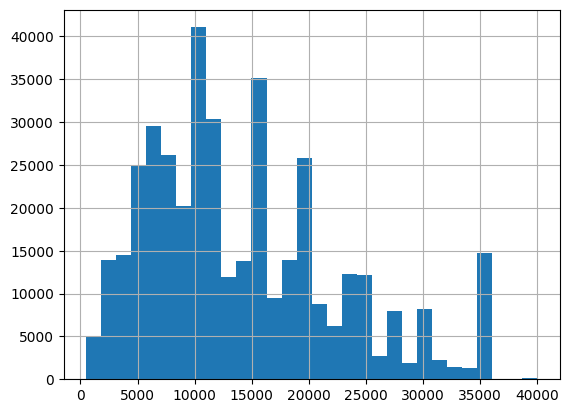

In [29]:
df['loan_amnt'].hist(bins=30)

- Multimodal
- The histogram is concentrated in the 5000-20,000 range.
- It is right skewed with frequency declining as loan amount increases with a long tail extending towards 40,000
- The appearance of multiple peaks suggests that the data comes from several groups or clusters.


<Axes: >

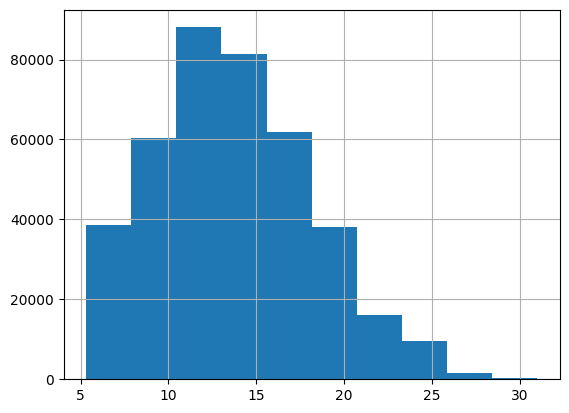

In [30]:
df['int_rate'].hist(bins=10)

- Unimodal
- The data is right skewed. Declining as the interest rate increases.
- The data is concentrated between 7 and 17 with a peak at 12-25.
- The frequency of the interest rate declines very low after 25. Suggesting extreme outliars.

<Axes: >

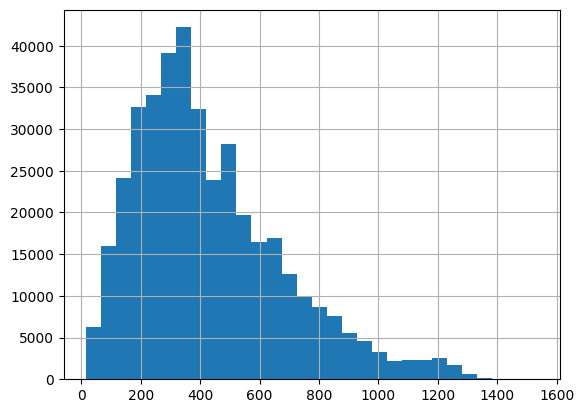

In [31]:
df['installment'].hist(bins=30)

- Unimodal
- The data in concentrated around 150-400 with a peak around 370.
- Right skewed with a long tail as the installemnt ammount increases.
- The frequency dips off after 1000 which can be interpreted as outliars.

In [32]:
df['annual_inc'].describe()

,annual_inc
count,3.960300e+05
mean,7.420318e+04
std,6.163762e+04
min,0.000000e+00
25%,4.500000e+04
50%,6.400000e+04
75%,9.000000e+04
max,8.706582e+06


- The min annual income value is 0 and the max is ~8M
- The 75% value is 90,000 which compared to max ~8M suggests that the annual income data is right skewed and has many outliars.

Note:  Pandas switches to scientific notation when numbers span a wide range, because printing 8000000.00 next to 4500.00 in a table is ugly and hard to align. It's purely display; the underlying values are exact.

In [33]:
df['dti'].describe()

,dti
count,396030.000000
mean,17.379514
std,18.019092
min,0.000000
25%,11.280000
50%,16.910000
75%,22.980000
max,9999.000000


- The mean is 17 and 75% is ~23 but the max is 9999 suggesting big outliars and heavily right skewed.

The Debt-to-Income (DTI) ratio is a personal finance measure that compares how much money you earn to how much you owe each month. It's a key metric lenders use to assess your ability to manage monthly payments and repay debts. A lower DTI ratio generally indicates that you have more income available to cover your debts, making you a less risky borrower.

<Axes: >

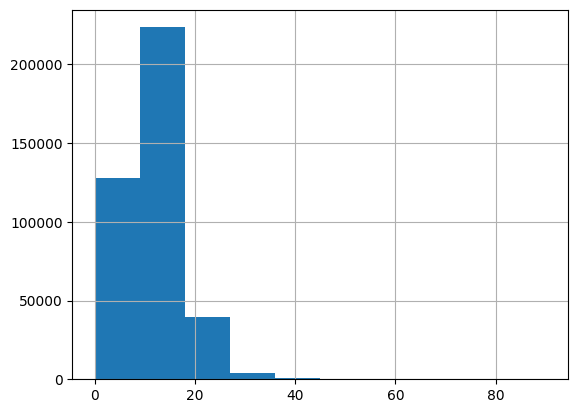

In [34]:
df['open_acc'].hist()

- Unimodal. Strong Right skewed. Concentrated on the 0-18 range.
- The long tail after 30 can be considered as outliars.

<Axes: >

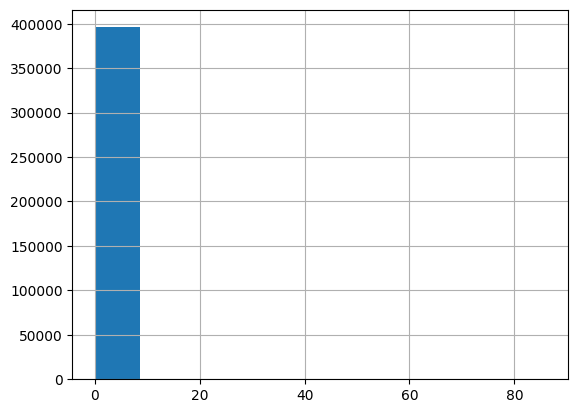

In [35]:
df['pub_rec'].hist()

In [36]:
df['pub_rec'].value_counts().head(5)

/tmp/ipykernel_2044/3449806657.py:1: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  df['pub_rec'].value_counts()[:5]


,count
pub_rec,
0.0,338272
1.0,49739
2.0,5476
3.0,1521
4.0,527
5.0,237


- Extreamly concentrated. Nearlt all values are between 0-10
- There are a few very large outliars.
- Unimodal and ~83% of data is 0.

In [37]:
df['revol_bal'].describe()

,revol_bal
count,3.960300e+05
mean,1.584454e+04
std,2.059184e+04
min,0.000000e+00
25%,6.025000e+03
50%,1.118100e+04
75%,1.962000e+04
max,1.743266e+06


- Extreme right skew, classic revolving-balance shape. Mean (15,844) > median, long tail of a few high-balance borrowers.
min = 0 is fine here (many people carry no revolving debt).

The `revol_bal` stands for Revolving Balance. This refers to the total outstanding balance that a borrower has across all their revolving credit accounts, such as credit cards and lines of credit. It represents the amount of money a borrower currently owes on their credit lines that they can continuously draw from and repay.

In [38]:
df['revol_util'].describe()

,revol_util
count,395754.000000
mean,53.791749
std,24.452193
min,0.000000
25%,35.800000
50%,54.800000
75%,72.900000
max,892.300000


`revolv_util` how much of your available revolving credit you're actually using, as a percentage.
Revolving credit = credit cards, lines of credit — limits you can borrow against repeatedly. If your cards total a 10,000 limit and you're carrying 3,000 in balance, your revol_util is 30%.

- Extreme right skew
- min = 0 is fine here (many people carry no revolving debt).
- Values above 100 are caused by fees compounding, interest, or the issuer allowing overage.

In [39]:
df['total_acc'].describe()

,total_acc
count,396030.000000
mean,25.414744
std,11.886991
min,2.000000
25%,17.000000
50%,24.000000
75%,32.000000
max,151.000000


- "Credit line" here = any credit account the borrower has ever had on file — not just active ones.
- So `total_acc` counts every account in their credit history: credit cards, auto loans, mortgages, student loans, store cards open or closed, all of it.
- Contrast with `open_acc`, which you also have: that's only the accounts currently open. So `total_acc` ≥ `open_acc` always (total includes the closed ones too).

In [53]:
df['mort_acc'].value_counts().head(5)

,count
mort_acc,
0.0,139777
1.0,60416
2.0,49948
3.0,38049
4.0,27887


- This is a

In [51]:
df['pub_rec_bankruptcies'].value_counts()

,count
pub_rec_bankruptcies,
0.0,350380
1.0,42790
2.0,1847
3.0,351
4.0,82
5.0,32
6.0,7
7.0,4
8.0,2


- Almost ~90% of people have no public record of bankruptcies.
- Intuitively this is a very important metric.

### To Dos:

- [ ] Change the object to category dtype and `issue_d`,`earliest_cr_line` to datetime type.
- [ ] Look into feature eng of 'title'
- [ ] We can extract parts of address into new feats like city, country and zip code during feature engineering.
 -[ ] Check the trend b/w interest rate, loan amount
 - [ ] installment vs loan anount vs loan period
 - Annual income has 0 data
 - Compare total_acc and open_acc
 - Use mortgage , credit default, open acc metrics to find trends. MAybe new good features from these.